In [1]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

In [2]:
file = "root://xrootd-cms.infn.it///store/mc/RunIII2024Summer24NanoAODv15/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v2/2540000/3eefd0bd-f08d-4c54-bb0b-7cccd19b4576.root"


factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [3]:
events.fields

['Dataset',
 'PV',
 'SoftActivityJetHT10',
 'L1',
 'GenProton',
 'SV',
 'FatJet',
 'SoftActivityJet',
 'OtherPV',
 'run',
 'TrackGenJetAK4',
 'IsoTrack',
 'PSWeight',
 'Tau',
 'orbitNumber',
 'LHE',
 'SoftActivityJetHT5',
 'RawPuppiMET',
 'DeepMETResolutionTune',
 'genWeight',
 'DST',
 'GenVtx',
 'LHEPart',
 'Jet',
 'LHEReweightingWeight',
 'DeepMETResponseTune',
 'Flag',
 'HTXS',
 'L1Reco',
 'TauProd',
 'L1simulation',
 'SoftActivityJetHT2',
 'SoftActivityJetHT',
 'RawPFMET',
 'Muon',
 'Rho',
 'GenPart',
 'GenVisTau',
 'luminosityBlock',
 'SoftActivityJetNjets2',
 'BeamSpot',
 'TauSpinner',
 'Photon',
 'SoftActivityJetNjets10',
 'GenJetAK8',
 'CorrT1METJet',
 'LowPtElectron',
 'boostedTau',
 'SoftActivityJetNjets5',
 'genTtbarId',
 'CaloMET',
 'HLT',
 'bunchCrossing',
 'event',
 'MC',
 'PFCand',
 'FatJetPFCand',
 'PVBS',
 'Electron',
 'HLTriggerFinalPath',
 'GenJet',
 'LHEScaleWeight',
 'SubJet',
 'FsrPhoton',
 'PuppiMET',
 'GenMET',
 'GenIsolatedPhoton',
 'LHEWeight',
 'FiducialMET',

In [ ]:
ak.num(events.Photon)
lead_pho = ak.first(events.Photon

<Array [1, 3, 1, 0, 1, 0, 1, 0, ..., 2, 1, 1, 0, 2, 0, 0] type='260898 * int64'>

In [6]:
import matplotlib.pyplot as plt

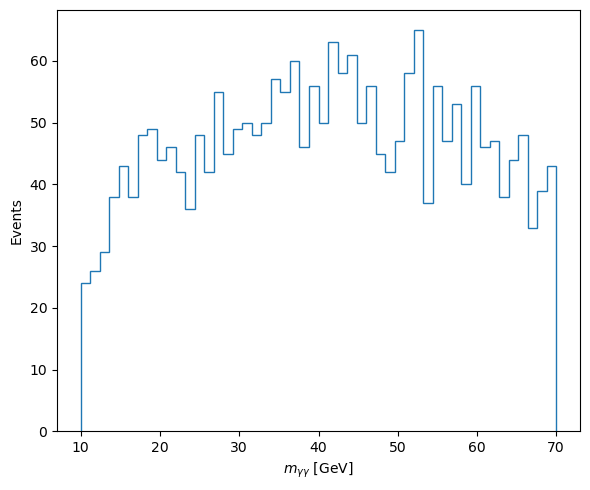

In [78]:
import vector

vector.register_awkward()

# Sort photons by pT (highest first)
photons = events.Photon[ak.argsort(events.Photon.pt, axis=1, ascending=False)]

photons = photons[photons.pt>10]

photons = photons[photons.mvaID >-0.3]

mask = ak.num(photons) >= 2

photons = photons[mask]

# Leading and subleading photons
lead = photons[:, 0]
sublead = photons[:, 1]

# Build 4-vectors
lead_p4 = ak.zip(
    {
        "pt": lead.pt,
        "eta": lead.eta,
        "phi": lead.phi,
        "mass": lead.mass,
    },
    with_name="Momentum4D",
)

sublead_p4 = ak.zip(
    {
        "pt": sublead.pt,
        "eta": sublead.eta,
        "phi": sublead.phi,
        "mass": sublead.mass,
    },
    with_name="Momentum4D",
)

# Diphoton mass
mgg = (lead_p4 + sublead_p4).mass

# Plot
plt.figure(figsize=(6,5))
plt.hist(ak.to_numpy(mgg), bins=50, range=(10,70), histtype="step")
plt.xlabel(r"$m_{\gamma\gamma}$ [GeV]")
plt.ylabel("Events")
plt.tight_layout()
plt.show()

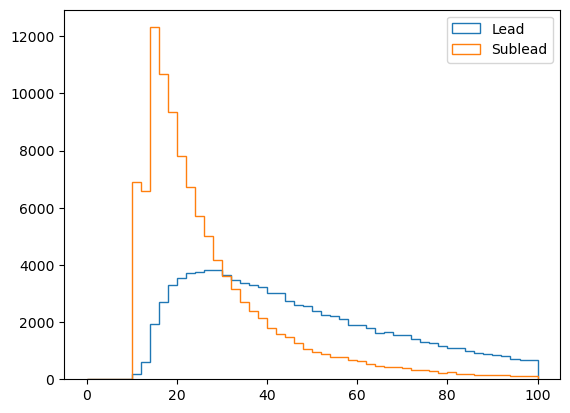

In [8]:
plt.hist(ak.to_numpy(lead.pt), bins=50, range=(0,100), histtype="step", label="Lead")
plt.hist(ak.to_numpy(sublead.pt), bins=50, range=(0,100), histtype="step", label="Sublead")
plt.legend()

Text(0.5, 0, '$\\Delta R(\\gamma_1,\\gamma_2)$')

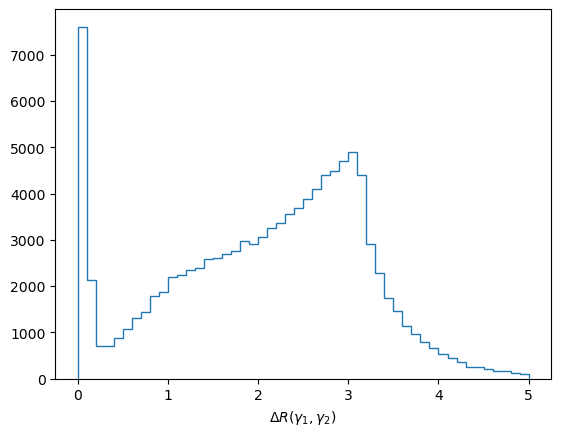

In [10]:
import numpy as np

lead = photons[:, 0]
sublead = photons[:, 1]

dphi = np.abs(lead.phi - sublead.phi)
dphi = np.where(dphi > np.pi, 2*np.pi - dphi, dphi)

deta = lead.eta - sublead.eta

dR = np.sqrt(deta**2 + dphi**2)

plt.hist(ak.to_numpy(dR), bins=50, range=(0,5), histtype="step")
plt.xlabel(r"$\Delta R(\gamma_1,\gamma_2)$")

In [44]:
dR_filter = dR<0.1

In [47]:
filtered_events = events[mask]
gen = filtered_events[dR_filter].GenPart

coll_pho = photons[dR_filter]

pho_idx = coll_pho[ak.num(coll_pho.pt)>0].genPartIdx
gen_photons = gen[pho_idx]

mother = gen[gen_photons.genPartIdxMother]

mpdg = mother.pdgId


In [48]:
mpdg

<Array [[521, -511, 521], ..., [-413, ...]] type='7602 * var * int32[parame...'>

In [29]:
filtered_events

<NanoEventsArray [<NanoAOD event>, ...] type='7602 * event'>

In [30]:
photons

<PhotonArray [[Photon, ..., Photon], ...] type='107852 * var * Photon[cutBa...'>

In [27]:
pho_idx

<Array [[68, -1, -1], [-1, ...], ..., [-1, -1]] type='107852 * var * int16[...'>

In [28]:
gen

<GenParticleArray [[GenParticle, GenParticle, ..., GenParticle, GenParticle], ...] type='...'>